# 🧠 Mental Health in Tech Industry Analysis

Name: Jay Jawalkar  
Roll No: DW241 

## Problem Statement

Mental health is a growing concern in the tech industry.  
This project analyzes survey data to understand what factors influence employees to seek mental health treatment.

## Dataset Description

Dataset: Mental Health in Tech Survey  
Source: Kaggle  
Rows: ~1250  
Columns: 27  

Includes demographic and workplace-related factors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Libraries imported for analysis and visualization.

In [2]:
df = pd.read_csv("mental_health.csv")

df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [3]:
df.shape
df.dtypes

Timestamp                      str
Age                          int64
Gender                         str
Country                        str
state                          str
self_employed                  str
family_history                 str
treatment                      str
work_interfere                 str
no_employees                   str
remote_work                    str
tech_company                   str
benefits                       str
care_options                   str
wellness_program               str
seek_help                      str
anonymity                      str
leave                          str
mental_health_consequence      str
phys_health_consequence        str
coworkers                      str
supervisor                     str
mental_health_interview        str
phys_health_interview          str
mental_vs_physical             str
obs_consequence                str
comments                       str
dtype: object

In [4]:
df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

In [5]:
df["Age"] = df["Age"].apply(lambda x: x if 15 <= x <= 80 else None)
df["Age"].fillna(df["Age"].median(), inplace=True)

C:\Users\jawal\AppData\Local\Temp\ipykernel_11560\2769345459.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Age"].fillna(df["Age"].median(), inplace=True)


0       37.0
1       44.0
2       32.0
3       31.0
4       31.0
        ... 
1254    26.0
1255    32.0
1256    34.0
1257    46.0
1258    25.0
Name: Age, Length: 1259, dtype: float64

In [7]:
def clean_gender(g):
    g = str(g).lower()
    if "male" in g:
        return "Male"
    elif "female" in g:
        return "Female"
    else:
        return "Other"


df["Gender"] = df["Gender"].apply(clean_gender)

In [9]:
for col in df.select_dtypes(include=["object"]).columns:
	df[col].fillna("Unknown", inplace=True)

C:\Users\jawal\AppData\Local\Temp\ipykernel_11560\409403489.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:
C:\Users\jawal\AppData\Local\Temp\ipykernel_11560\409403489.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing

In [10]:
df.drop(["Timestamp", "comments", "state"], axis=1, inplace=True)

In [11]:
df.drop_duplicates(inplace=True)

Data cleaned by fixing age, standardizing gender, and handling missing values.

In [12]:
df["Age"].mean()
df["Age"].median()
df["Age"].std()
df["Age"].var()

np.float64(53.24852068720949)

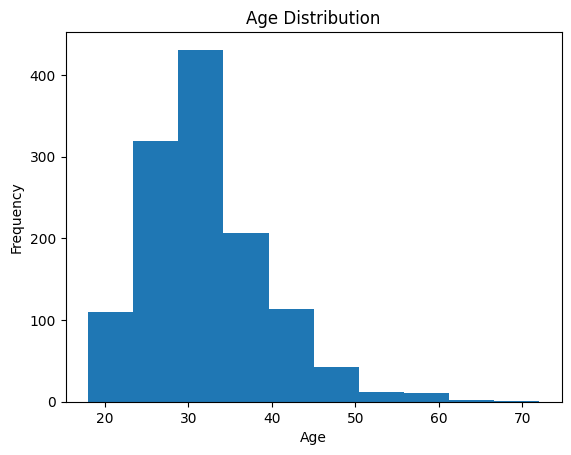

In [13]:
plt.hist(df["Age"])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

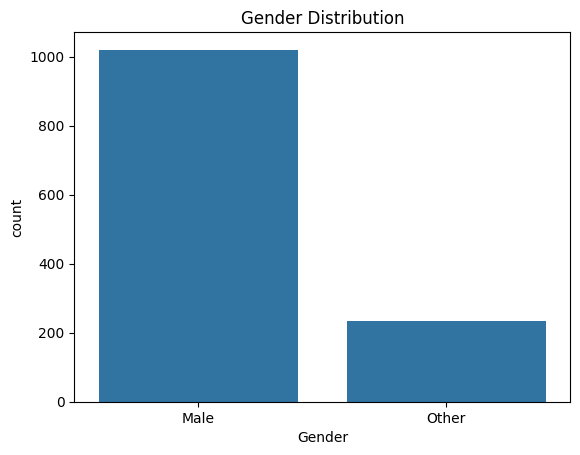

In [14]:
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

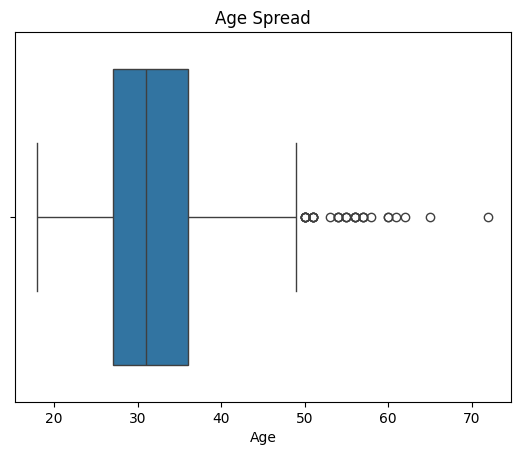

In [15]:
sns.boxplot(x=df["Age"])
plt.title("Age Spread")
plt.show()

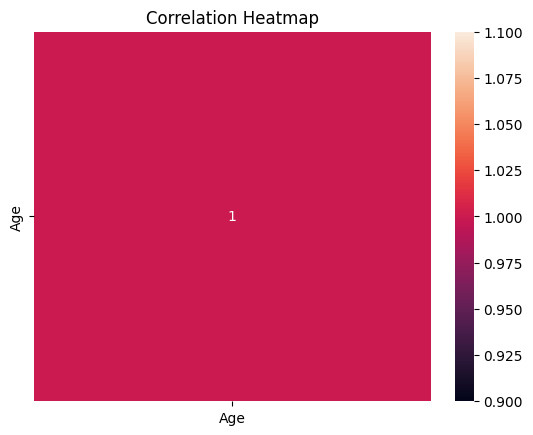

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop("treatment", axis=1)
y = df["treatment"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.6932270916334662

The model predicts whether a person seeks treatment based on workplace and personal factors.

## Insights

- Most respondents are young adults  
- Work interference increases treatment likelihood  
- Dataset is male dominated  

## Recommendations

- Promote mental health awareness  
- Provide anonymous support systems  